(05-28-termijnstructuur-premies)=

# Fama-Bliss, Cochrane-Piazzesi en het string-model

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1987–2018: van Fama en Bliss via het rentewerk van Santa-Clara rond
2001 en Cochrane en Piazzesi in 2005 tot de kritiek van Bauer en Hamilton.

**Wat we al weten.** In [](#03-17-termijnstructuur-real-options) prijsden Vasicek
en CIR de hele rentecurve met één factor en een constante marktprijs van risico. Een
principale-componentenanalyse op de GSW-curve vond daar drie factoren, en de lange
rente bleek op eigen kracht te bewegen. [](#04-20-voorspelbaarheid) liet zien dat
verwachte aandelenrendementen variëren, maar ook dat het bewijs in kleine, vertekende
hellingen met overlappende waarnemingen zit. [](#05-27-drie-antwoorden) gaf drie
modellen waarin de prijs van risico door de tijd beweegt.

**Welke vraag staat open.** Is het extra rendement op lange obligaties constant,
zoals de expectations hypothesis zegt, en zo niet: welke vorm van de curve voorspelt
het, en hoeveel factoren heeft die curve eigenlijk?
```

## Overzicht

Stelling 8 in de lijst "What we know" van Pedro Santa-Clara luidt: "Long bonds carry
a risk premium that varies over time and is forecastable from the shape of the yield
curve. Forward rates are not unbiased forecasts of future short rates"
{cite}`SantaClara2026`. Dat is een ontkenning van de oudste theorie over de
rentecurve: de *expectations hypothesis* (verwachtingenhypothese: een lange rente is
het gemiddelde van de verwachte toekomstige korte rentes, plus hooguit een constante).
Die hypothese gaat terug op {cite:t}`Fisher1896`, werd door {cite:t}`Hicks1939`
aangevuld met een liquiditeitspremie en door {cite:t}`Lutz1940` uitgewerkt tot een
formule die elke looptijd uit de verwachte korte rentes opbouwt.

Twee regressies brachten haar ten val. {cite:t}`FamaBliss1987` regresseerden het
extra rendement van een $n$-jaarsobligatie op het verschil tussen de $n$-jaars
*forward rate* (termijnrente: de rente die je vandaag kunt vastleggen voor een lening
die over $n-1$ jaar begint) en de éénjaarsrente; onder de hypothese zou die helling
nul zijn, en ze is rond één. {cite:t}`CampbellShiller1991` regresseerden de
verandering van de lange rente op de *yield spread* (het verschil tussen lange en
korte rente); onder de hypothese zou die helling één zijn, en ze is negatief.
{cite:t}`CochranePiazzesi2005` lieten zien dat één tentvormige combinatie van vijf
forward rates de extra rendementen van álle looptijden voorspelt, met een $R^2$ tot
0,44, en dat die factor niet samenvalt met level, slope of curvature. Epistemisch is
dit een lecture over een theorie die getoetst en verworpen werd (motief 3), en over
een feit dat sindsdien op een theorie wacht. {cite:t}`LudvigsonNg2009`,
{cite:t}`Duffee2011` en {cite:t}`BauerHamilton2018` debatteren nog over wat dat feit
precies is.

De tweede helft gaat over Santa-Clara's eigen werk. Als de curve niet door drie factoren wordt
gedreven maar door een continuüm aan gecorreleerde schokken, het *string-model* van
{cite:t}`SantaClaraSornette2001`, dan prijzen eindig-factormodellen producten die op
correlaties tussen looptijden leunen verkeerd; {cite:t}`LongstaffSantaClaraSchwartz2001a`
vonden dat bij caps en swaptions. We repliceren op de GSW-curve de Fama-Bliss-tabel, de tent
van Cochrane en Piazzesi, de hellingen van Campbell en Shiller en de correlatiestructuur van
forward-veranderingen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Wie vijf jaar wil beleggen, kan een obligatie van vijf jaar kopen of vijf keer achter
elkaar een obligatie van één jaar. Als beleggers alleen om verwachte opbrengst geven,
moeten die twee routes gemiddeld hetzelfde opleveren. Dan zegt de rentecurve van vandaag
alles over de korte rentes van morgen: een stijgende curve betekent dat de markt
stijgende rentes verwacht, en een forward rate is de beste voorspelling van de korte
rente op dat moment. Dat is de expectations hypothesis. Ze klinkt als no-arbitrage, maar de twee routes hebben
verschillend risico: wie de lange obligatie na een jaar verkoopt, weet vandaag niet tegen
welke prijs.

Neem nu de data. Als de curve steil is, stijgen de lange rentes het jaar daarop niet,
zoals de hypothese vereist; ze dalen eerder. Wie bij een steile curve de lange obligatie
kocht, verdiende daardoor gemiddeld meer dan de korte rente, en ongeveer precies het
verschil dat de curve aangaf. De steilheid van de curve voorspelt dus niet de rente,
maar het extra rendement. Dat extra rendement is een risicopremie die in de tijd beweegt.

Dan de verrassing van Cochrane en Piazzesi. Forward rates van één tot vijf jaar bewegen bijna
volledig samen: verschuiving, kanteling en buiging verklaren meer dan 99% van hun variantie.
Toch zit de voorspellende informatie deels in een vorm die in die variantie nauwelijks
meetelt, een tent met een top in het midden. Een factor die klein is voor rentes kan groot
zijn voor verwachte rendementen.

Het string-model kijkt naar dezelfde curve vanuit prijzen. Als elke looptijd een eigen schok
krijgt, gecorreleerd met die van zijn buren, is de correlatie tussen de twee- en de
driejaarsrente hoog en die tussen de één- en de tienjaarsrente lager; een eenfactormodel zet
ze allemaal op één. Een cap is een reeks opties op afzonderlijke forward rates en hangt alleen
van hun volatiliteiten af, een swaption is een optie op een gemiddelde van forwards en hangt
ook van hun correlaties af. Een model met te hoge correlaties dat caps goed prijst, prijst
swaptions dus te hoog. Santa-Clara noemt zijn model "an infinite-factor generalization of
Heath, Jarrow and Morton" {cite}`SantaClara2026`.

## Toy-voorbeeld: drie looptijden op twee datums

Op datum $t$ kosten nulcouponobligaties die over één, twee en drie jaar één euro
uitkeren $P^{(1)}_t = 0{,}95$, $P^{(2)}_t = 0{,}90$ en $P^{(3)}_t = 0{,}84$. Een jaar
later kosten de obligaties van één en twee jaar $P^{(1)}_{t+1} = 0{,}94$ en
$P^{(2)}_{t+1} = 0{,}88$. De obligatie die op $t$ drie jaar liep, loopt op $t+1$ nog
twee jaar en kost dus 0,88.

**Log-prijzen en yields.** Met $p = \log P$ en $y^{(n)} = -p^{(n)}/n$:

$$
\begin{aligned}
p^{(1)}_t &= -0{,}051293, & p^{(2)}_t &= -0{,}105361, & p^{(3)}_t &= -0{,}174353,\\
y^{(1)}_t &= 5{,}1293\%, & y^{(2)}_t &= 5{,}2680\%, & y^{(3)}_t &= 5{,}8118\%,
\end{aligned}
$$

en op $t+1$: $p^{(1)}_{t+1} = -0{,}061875$, $p^{(2)}_{t+1} = -0{,}127833$, dus
$y^{(1)}_{t+1} = 6{,}1875\%$ en $y^{(2)}_{t+1} = 6{,}3916\%$.

**Forward rates.** De forward rate voor het jaar van $t+n-1$ naar $t+n$ is het verschil
van twee log-prijzen: $f^{(2)}_t = p^{(1)}_t - p^{(2)}_t = 5{,}4067\%$ en
$f^{(3)}_t = p^{(2)}_t - p^{(3)}_t = 6{,}8993\%$. Wie op $t$ één euro van de
driejaars- in de tweejaarsobligatie ruilt, legt die rente vast voor het derde jaar.

**Rendementen.** Het log-rendement van de driejaarsobligatie over het eerste jaar is
$r^{(3)}_{t+1} = p^{(2)}_{t+1} - p^{(3)}_t = -0{,}127833 + 0{,}174353 = 4{,}6520\%$, en
het extra rendement boven de éénjaarsrente is
$rx^{(3)}_{t+1} = 4{,}6520\% - 5{,}1293\% = -0{,}4773\%$. Voor de tweejaarsobligatie:
$rx^{(2)}_{t+1} = -0{,}061875 + 0{,}105361 - 0{,}051293 = -0{,}7808\%$ (op onafgeronde log-prijzen). De rente
steeg dat jaar, dus lange obligaties deden het slechter dan kort beleggen.

**De identiteit.** De forward spread $f^{(3)}_t - y^{(1)}_t = 1{,}7700\%$ splitst exact
in het extra rendement en twee keer de verandering van de tweejaarsrente:

$$
f^{(3)}_t - y^{(1)}_t = rx^{(3)}_{t+1} + 2\,\big(y^{(2)}_{t+1} - y^{(2)}_t\big)
= -0{,}4773\% + 2 \times 1{,}1236\% = 1{,}7700\% .
$$

Neem van beide kanten de verwachting op $t$. De forward spread is dan de som van een
verwacht extra rendement en een verwachte renteverandering. De expectations hypothesis
zegt dat de eerste term constant is, hier nul. Dan voorspelt de curve dat de
tweejaarsrente met $1{,}7700\%/2 = 0{,}8850$ procentpunt stijgt, naar $6{,}1530\%$, en
dat de tweejaarsobligatie op $t+1$ $e^{-2 \times 0{,}061530} = 0{,}8842$ kost. Ze kostte
0,88: de rente steeg met 1,1236 procentpunt, meer dan voorspeld, en het verschil
verscheen als een negatief extra rendement. Eén jaar zegt niets over de hypothese; de vraag is welke term de spread gemiddeld draagt.

In [2]:
prices_t = {1: 0.95, 2: 0.90, 3: 0.84}
prices_t1 = {1: 0.94, 2: 0.88}
p_t = {n: np.log(v) for n, v in prices_t.items()}
p_t1 = {n: np.log(v) for n, v in prices_t1.items()}
y_t = {n: -p_t[n] / n for n in p_t}
y_t1 = {n: -p_t1[n] / n for n in p_t1}

fwd_toy = {2: p_t[1] - p_t[2], 3: p_t[2] - p_t[3]}
rx_toy = {2: p_t1[1] - p_t[2] - y_t[1], 3: p_t1[2] - p_t[3] - y_t[1]}
spread_toy = fwd_toy[3] - y_t[1]
yield_change_toy = 2 * (y_t1[2] - y_t[2])
eh_y2 = y_t[2] + spread_toy / 2

print("yields t   (%):", [round(100 * float(y_t[n]), 4) for n in (1, 2, 3)], " hand: 5.1293, 5.2680, 5.8118")
print("forwards   (%):", round(100 * fwd_toy[2], 4), round(100 * fwd_toy[3], 4), " hand: 5.4067, 6.8993")
print("rx^(2), rx^(3) (%):", round(100 * rx_toy[2], 4), round(100 * rx_toy[3], 4), " hand: -0.7808, -0.4773")
print(f"f3 - y1 = {100 * spread_toy:.4f}%,  rx3 + 2*dy2 = {100 * (rx_toy[3] + yield_change_toy):.4f}%  (hand: 1.7700)")
print(f"EH: E[y2 op t+1] = {100 * eh_y2:.4f}%, prijs {np.exp(-2 * eh_y2):.4f}  (hand: 6.1530%, 0.8842)")
assert np.isclose(spread_toy, rx_toy[3] + yield_change_toy)
assert abs(100 * rx_toy[3] + 0.4773) < 5e-5 and abs(100 * spread_toy - 1.7700) < 5e-5

yields t   (%): [5.1293, 5.268, 5.8118]  hand: 5.1293, 5.2680, 5.8118
forwards   (%): 5.4067 6.8993  hand: 5.4067, 6.8993
rx^(2), rx^(3) (%): -0.7808 -0.4773  hand: -0.7808, -0.4773
f3 - y1 = 1.7700%,  rx3 + 2*dy2 = 1.7700%  (hand: 1.7700)
EH: E[y2 op t+1] = 6.1530%, prijs 0.8842  (hand: 6.1530%, 0.8842)


De code geeft dezelfde getallen, en de identiteit sluit op machineprecisie: ze volgt
uit de definities en niet uit een model.

## Theorie

### Definities

Vanaf hier zijn kleine letters logs. Het superscript tussen haakjes is de looptijd in
jaren en de tijdstap is één jaar, ook als we straks maandelijks waarnemen. We volgen de
notatie van Cochrane en Piazzesi en schrijven het extra rendement als $rx$ in plaats van
de $R^{e}$ uit de notatietabel: het gaat om log-rendementen per looptijd, en $rx^{(n)}$
leest beter dan $r^{e,(n)}$.

:::{prf:definition} Prijzen, yields, forwards en rendementen
:label: def-termijnstructuur-premies-notatie

Laat $p^{(n)}_t$ de log-prijs op $t$ zijn van een nulcouponobligatie die op $t+n$ één
euro uitkeert, met $p^{(0)}_t = 0$. Dan zijn

- de **yield**: $y^{(n)}_t = -\tfrac1n\, p^{(n)}_t$;
- de **forward rate** voor het jaar van $t+n-1$ tot $t+n$: $f^{(n)}_t = p^{(n-1)}_t - p^{(n)}_t$;
- het **holding-period return** (het rendement van een jaar houden en verkopen):
  $r^{(n)}_{t+1} = p^{(n-1)}_{t+1} - p^{(n)}_t$;
- het **extra rendement**: $rx^{(n)}_{t+1} = r^{(n)}_{t+1} - y^{(1)}_t$;
- de **forward spread**: $f^{(n)}_t - y^{(1)}_t$, en de **yield spread**: $y^{(n)}_t - y^{(1)}_t$.
:::

De yield is het gemiddelde van de forwards, $y^{(n)}_t = \tfrac1n\sum_{k=1}^{n} f^{(k)}_t$ met
$f^{(1)}_t = y^{(1)}_t$.

### De expectations hypothesis in drie gedaanten

*Waarom zou dit waar zijn?* Als beleggers risiconeutraal zijn, levert elke manier om een jaar
te beleggen in verwachting hetzelfde op. Hicks voegde een vaste vergoeding voor prijsrisico toe.
De hypothese staat of valt dus met de vraag of de premie *constant* is.

:::{prf:definition} Expectations hypothesis
:label: def-termijnstructuur-premies-eh

De expectations hypothesis (EH) houdt in dat voor elke looptijd $n$ een constante $c_n$
bestaat met

```{math}
:label: eq-termijnstructuur-premies-eh-yield
y^{(n)}_t = \frac1n \sum_{i=0}^{n-1} \E_t\big[y^{(1)}_{t+i}\big] + c_n .
```

Met $c_n = 0$ heet ze de pure EH; met $c_n \ne 0$ laat ze een constante term premium toe.
:::

:::{prf:theorem} Drie equivalente vormen
:label: thm-termijnstructuur-premies-eh

De volgende uitspraken zijn equivalent:

1. [](#eq-termijnstructuur-premies-eh-yield) geldt voor alle $n$;
2. voor alle $n$ is $f^{(n)}_t = \E_t\big[y^{(1)}_{t+n-1}\big] + a_n$ met $a_n$ constant;
3. voor alle $n$ is $\E_t\big[rx^{(n)}_{t+1}\big] = b_n$ met $b_n$ constant.
:::

:::{prf:proof}
Uit de definitie van $rx$ volgt voor elke $n \ge 1$ de exacte recursie
$p^{(n)}_t = p^{(n-1)}_{t+1} - y^{(1)}_t - rx^{(n)}_{t+1}$. Neem de verwachting op $t$ en
herhaal de substitutie voor $p^{(n-1)}_{t+1}$, $p^{(n-2)}_{t+2}$, tot $p^{(0)} = 0$:

$$
-p^{(n)}_t = \sum_{i=0}^{n-1} \E_t\big[y^{(1)}_{t+i}\big]
          + \sum_{i=0}^{n-1} \E_t\big[rx^{(n-i)}_{t+1+i}\big] .
$$

(3) ⇒ (1): zijn de verwachte extra rendementen constant, dan is de tweede som constant; deel
door $n$. (1) ⇒ (3): trek de identiteit voor $n-1$, geschoven naar $t+1$ en in verwachting op
$t$, af van die voor $n$; er blijft $\E_t[rx^{(n)}_{t+1}] = n c_n - (n-1) c_{n-1}$ over.
(1) ⇔ (2): vul [](#eq-termijnstructuur-premies-eh-yield) in
$f^{(n)}_t = n y^{(n)}_t - (n-1) y^{(n-1)}_t$ in; van de sommen blijft
$\E_t[y^{(1)}_{t+n-1}]$ over, plus $a_n = n c_n - (n-1)c_{n-1}$. $\square$
:::

De derde vorm is de toetsbare: onder de EH is geen enkele variabele op $t$ in staat
extra obligatierendementen te voorspellen. Het is de obligatieversie van het constante verwachte rendement uit
[](#04-20-voorspelbaarheid).



### De identiteit achter beide regressies

*Waarom zou dit waar zijn?* Ligt de forward rate boven de korte rente, dan moet dat verschil
ergens heen: óf de langere rente stijgt, zodat wie lang koopt koersverlies lijdt, óf wie lang
koopt verdient het als extra rendement.

:::{prf:proposition} Forward spread = verwacht extra rendement + verwachte renteverandering
:label: thm-termijnstructuur-premies-identiteit

Voor elke $n \ge 2$ geldt exact

```{math}
:label: eq-termijnstructuur-premies-identiteit
f^{(n)}_t - y^{(1)}_t = rx^{(n)}_{t+1} + (n-1)\big(y^{(n-1)}_{t+1} - y^{(n-1)}_t\big),
```

en dus ook met $\E_t$ voor beide termen rechts. Laat $\beta_{rx}$ en $\beta_{\Delta y}$
de OLS-hellingen zijn van de twee termen rechts op de forward spread, in dezelfde
steekproef. Dan is $\beta_{rx} + \beta_{\Delta y} = 1$.
:::

:::{prf:proof}
Invullen van de definities: $rx^{(n)}_{t+1} = p^{(n-1)}_{t+1} - p^{(n)}_t + p^{(1)}_t$ en
$(n-1)(y^{(n-1)}_{t+1} - y^{(n-1)}_t) = -p^{(n-1)}_{t+1} + p^{(n-1)}_t$. De som is
$p^{(n-1)}_t - p^{(n)}_t + p^{(1)}_t = f^{(n)}_t - y^{(1)}_t$. De hellingen tellen op tot
één omdat OLS lineair is in de afhankelijke variabele en de spread op zichzelf helling
één heeft. $\square$
:::

Dit is het toy-voorbeeld in algemene vorm. De regressie van {cite:t}`FamaBliss1987`

```{math}
:label: eq-termijnstructuur-premies-fb
rx^{(n)}_{t+1} = \alpha_n + \beta_n\big(f^{(n)}_t - y^{(1)}_t\big) + \varepsilon^{(n)}_{t+1}
```

toetst de EH als $H_0: \beta_n = 0$. Het alternatief waar de data op wijzen is het
omgekeerde uiterste, $\beta_n = 1$: de spread is volledig premie en de lange rente
beweegt gemiddeld niet in de voorspelde richting. Een helling boven één betekent dat de
rente zelfs *tegen* de spread in beweegt.

### Campbell en Shiller: de helling die één had moeten zijn

*Waarom zou dit waar zijn?* Klopt de EH, dan moet de lange rente bij een steile curve precies
genoeg stijgen om de extra coupon weg te nemen. De regressie meet hoeveel daarvan gebeurt.

{cite:t}`CampbellShiller1991` schatten

```{math}
:label: eq-termijnstructuur-premies-cs
y^{(n-1)}_{t+1} - y^{(n)}_t = a_n + b_n\,\frac{y^{(n)}_t - y^{(1)}_t}{n-1} + u_{t+1},
```

met onder de EH $b_n = 1$. Deze regressie en die van Fama en Bliss meten hetzelfde
feit, maar met een ander stuk van de identiteit.

:::{prf:proposition} Het verband tussen Campbell-Shiller en Fama-Bliss
:label: thm-termijnstructuur-premies-cs-fb

Laat $s_t = y^{(n)}_t - y^{(1)}_t$ en laat $\beta^{s}_n$ de OLS-helling zijn van
$rx^{(n)}_{t+1}$ op $s_t$. Dan geldt in elke steekproef $b_n = 1 - \beta^{s}_n$. Voor
$n = 2$ is $f^{(2)}_t - y^{(1)}_t = 2 s_t$, zodat $b_2 = 1 - 2\beta_2$, met $\beta_2$ de
Fama-Bliss-helling uit [](#eq-termijnstructuur-premies-fb).
:::

:::{prf:proof}
Uit de definities volgt exact
$rx^{(n)}_{t+1} = s_t - (n-1)\big(y^{(n-1)}_{t+1} - y^{(n)}_t\big)$: werk rechts uit tot
$-(n-1)y^{(n-1)}_{t+1} + n y^{(n)}_t - y^{(1)}_t = p^{(n-1)}_{t+1} - p^{(n)}_t - y^{(1)}_t$.
De linkerkant van [](#eq-termijnstructuur-premies-cs) is dus $(s_t - rx^{(n)}_{t+1})/(n-1)$
en de regressor $s_t/(n-1)$. De factor $1/(n-1)$ valt uit de helling, en de helling van
$s_t - rx^{(n)}_{t+1}$ op $s_t$ is $1 - \beta^s_n$. Voor $n=2$ is
$f^{(2)} - y^{(1)} = p^{(1)} - p^{(2)} + p^{(1)} = 2y^{(2)} - 2y^{(1)}$. $\square$
:::

Een Fama-Bliss-helling van één op de forward spread voor $n=2$ geeft dus
$b_2 = -1$: elke procentpunt spread gaat samen met een *daling* van de lange rente. De
negatieve Campbell-Shiller-hellingen en de positieve Fama-Bliss-hellingen zijn geen twee
anomalieën maar één. In de NBER-versie van hun artikel (werkpaper 3153, tabel 1b,
1952–1987, maandelijkse horizon) vinden Campbell en Shiller $b = -1{,}815$ (standaardfout
1,151) voor een looptijd van 24 maanden, $-3{,}099$ (1,749) voor 60 maanden en
$-5{,}024$ (2,316) voor 120 maanden. De hellingen worden negatiever naarmate de looptijd
langer is.

### Cochrane en Piazzesi: één factor voor alle looptijden

*Waarom zou dit waar zijn?* Is er één bron van tijdvariërend risico, dan bewegen de verwachte
extra rendementen van alle looptijden door die ene toestandsvariabele, alleen sterker naarmate
de obligatie langer loopt. Eén portefeuille van forward rates volstaat dan voor allemaal.

Cochrane en Piazzesi begonnen met de onbeperkte regressie van elk extra rendement op
alle vijf forwards, $rx^{(n)}_{t+1} = \boldsymbol\beta_n'\mathbf f_t + \varepsilon^{(n)}_{t+1}$
met $\mathbf f_t = (1, y^{(1)}_t, f^{(2)}_t, \dots, f^{(5)}_t)'$, en zagen dat de vier
coëfficiëntvectoren dezelfde vorm hebben, alleen geschaald. Dat is de restrictie
$\boldsymbol\beta_n = b_n\boldsymbol\gamma$, of

```{math}
:label: eq-termijnstructuur-premies-cp
rx^{(n)}_{t+1} = b_n\big(\boldsymbol\gamma'\mathbf f_t\big) + \varepsilon^{(n)}_{t+1},
\qquad \frac14\sum_{n=2}^{5} b_n = 1 .
```

:::{prf:algorithm} De Cochrane-Piazzesi-schatting in twee stappen
:label: alg-termijnstructuur-premies-cp

1. Middel de extra rendementen over de looptijden,
   $\overline{rx}_{t+1} = \tfrac14\sum_{n=2}^{5} rx^{(n)}_{t+1}$, en regresseer met OLS op
   alle forwards: $\overline{rx}_{t+1} = \boldsymbol\gamma'\mathbf f_t + \bar\varepsilon_{t+1}$.
   De fitted value $\hat x_t = \hat{\boldsymbol\gamma}'\mathbf f_t$ is de
   *return-forecasting factor*.
2. Regresseer per looptijd $rx^{(n)}_{t+1}$ zonder constante op $\hat x_t$; de helling is
   $\hat b_n$. Omdat de gemiddelde helling op $\overline{rx}$ precies één is, geldt de
   normalisatie $\tfrac14\sum\hat b_n = 1$ vanzelf.
:::

Hun tabel 1 (maandelijkse waarnemingen van jaarlijkse rendementen, 1964–2003,
Fama-Bliss-data van CRSP) geeft gewichten die negatief zijn op de éénjaarsrente, een top
hebben op de derde forward en weer negatief zijn op de vijfde: de tent, met $R^2 = 0{,}35$
voor het gemiddelde extra rendement en 0,31–0,37 per looptijd, bijna gelijk aan de
onbeperkte regressies. Hun tabel 2 geeft voor de Fama-Bliss-regressies op dezelfde data
$R^2$ van 0,09 tot 0,18. De $R^2$ van 0,44 uit hun abstract komt uit tabel 5: met drie maanden vertraagde
forwards erbij loopt de $R^2$ op van 0,35 via 0,41 en 0,43 naar 0,44. Cochrane en
Piazzesi lezen dat als een teken van meetfouten in de prijzen: een gemiddelde over
opeenvolgende maanden dempt de ruis.

De oorspronkelijke tabel van Fama en Bliss (1987) hebben we niet kunnen inzien; we
vergelijken daarom met de update in tabel 2 van Cochrane en Piazzesi, die volgens hen
"have held up well since publication, unlike many other anomalies".

### Waarom de premie niet in de PCA hoeft te zitten

*Waarom zou dit waar zijn?* Een PCA ordent richtingen in de curve naar hun *variantie*, een
voorspellende regressie naar hun *covariantie* met toekomstige rendementen, en die schaalt de
regressor zelf op. Een richting met weinig variantie kan dus een grote $R^2$ opleveren.

:::{prf:proposition} Schaalinvariantie en de verborgen factor
:label: thm-termijnstructuur-premies-verborgen

(i) Voor elke vector $\mathbf w \ne 0$ en elke $c \ne 0$ is de $R^2$ van $rx^{(n)}_{t+1}$ op
$\mathbf w'\mathbf f_t$ gelijk aan die op $c\,\mathbf w'\mathbf f_t$. De $R^2$ van een
voorspeller hangt dus niet af van het aandeel van $\mathbf w'\mathbf f_t$ in de variantie
van de curve.

(ii) Laat een toestandsvariabele $h_t$ het verwachte extra rendement van elke looptijd
verhogen met $\delta_n h_t$ en tegelijk de verwachte verandering van de
$(n-1)$-jaarsrente verlagen met $\delta_n h_t/(n-1)$. Dan verandert $h_t$ geen enkele
forward rate, en dus geen enkele yield.
:::

:::{prf:proof}
(i) De $R^2$ van een enkelvoudige regressie is het kwadraat van de correlatie, en een
correlatie verandert niet onder schaling. (ii) Volgt direct uit
[](#eq-termijnstructuur-premies-identiteit) met $\E_t$: de linkerkant verandert niet als
de twee termen rechts in tegengestelde richting evenveel bewegen. $\square$
:::

Deel (i) is de situatie van Cochrane en Piazzesi: in hun tabel 4 halen level, slope en
curvature samen een $R^2$ van 0,26 tegen 0,35 voor alle vijf forwards, en de 4-5-jaarsspread
is volgens hen "a tiny factor for yields" die toch veel over verwachte rendementen zegt. Deel
(ii) is het extreme geval dat {cite:t}`Duffee2011` in de data vond: "almost half of the
variation in bond risk premia" is niet te zien in de cross-sectie van yields. Zo'n factor vind
je alleen met variabelen van buiten de curve, zoals de macrofactoren van
{cite:t}`LudvigsonNg2009`. Economisch is dat geen toeval: een recessie die de premie verhoogt en
tegelijk renteverlagingen doet verwachten, kan de curve per saldo ongemoeid laten.

### Overlappende waarnemingen: Hansen-Hodrick en Newey-West

*Waarom zou dit waar zijn?* Jaarrendementen die elke maand worden gemeten, delen elf maanden
met hun buren; een gewone standaardfout telt ze als onafhankelijk.

Schrijf de OLS-schatter als $\hat{\boldsymbol\beta} - \boldsymbol\beta =
(\mathbf X'\mathbf X)^{-1}\sum_t \mathbf x_t\varepsilon_{t+12}$. Onder de nulhypothese
volgt $\varepsilon$ een MA(11), dus $\mathbf g_t = \mathbf x_t\varepsilon_{t+12}$ is
gecorreleerd tot en met vertraging 11, en

```{math}
:label: eq-termijnstructuur-premies-hac
\widehat{\Var}\big(\hat{\boldsymbol\beta}\big) = (\mathbf X'\mathbf X)^{-1}
\Big[\sum_{j=-L}^{L} w_j \sum_t \hat{\mathbf g}_t\hat{\mathbf g}_{t-j}'\Big]
(\mathbf X'\mathbf X)^{-1} .
```

{cite:t}`HansenHodrick1980` nemen $w_j = 1$ tot $L = 11$ of 12, precies de MA-structuur, maar
niet noodzakelijk positief definiet; {cite:t}`NeweyWest1987` nemen $w_j = 1 - |j|/(L+1)$, altijd
positief semidefiniet, maar met een grotere $L$ nodig.
Cochrane en Piazzesi rapporteren beide: de $\chi^2(5)$-toets op hun vijf forwards is 811 met
Hansen-Hodrick (12 vertragingen) en 105 met Newey-West (18).

```{warning}
Beide correcties zijn asymptotisch. Met een persistente regressor, overlap en veertig jaar data
verwerpen ze te vaak, en de $R^2$ is opwaarts vertekend. {cite:t}`BauerHamilton2018` toetsen de
*spanning hypothesis* (dat level, slope en curvature alle voorspellende informatie bevatten) en
noemen de gangbare toetsen "subject to serious small-sample distortions"; na hun bootstrap
vinden ze "that the evidence against the spanning hypothesis is much weaker than it originally
appeared". Het is de valkuil van [](#04-20-voorspelbaarheid) in een andere markt.
```

### Van eindig veel factoren naar een string

*Waarom zou dit waar zijn?* Een obligatie is een integraal over forward rates. Kies je de
dynamiek van de hele forwardcurve, dan ligt de risiconeutrale drift van elke forward vast door de
eis dat verdisconteerde obligatieprijzen martingalen zijn; welke schokken de curve krijgt, is vrij.

Dit is de benadering van {cite:t}`HeathJarrowMorton1992` (HJM). Laat $f(t,T)$ de
instantane forward rate op $t$ voor looptijd $T$ zijn en $P(t,T) = \exp(-\int_t^T
f(t,u)\,\mathrm du)$. Een $K$-factor-HJM-model schrijft onder $\mathbb Q$

$$
\mathrm d f(t,T) = \alpha(t,T)\,\mathrm dt + \sum_{k=1}^{K}\sigma_k(t,T)\,\mathrm dW_k(t) .
$$

{cite:t}`SantaClaraSornette2001` gaven elke looptijd een eigen schok, "constrained in such a way
as to keep the forward rate curve continuous": een *stochastic string* (een willekeurig veld
$Z(t,T)$, in $t$ een Brownse beweging en in $T$ continu). Voor ons volstaat de
covariantiestructuur:

```{math}
:label: eq-termijnstructuur-premies-string
\mathrm d f(t,T) = \alpha(t,T)\,\mathrm dt + \sigma(t,T)\,\mathrm dZ(t,T),
\qquad
\Corr\big(\mathrm dZ(t,T_1),\ \mathrm dZ(t,T_2)\big) = c(T_1 - t,\ T_2 - t) .
```

Het $K$-factormodel is het speciale geval waarin de covariantiekern
$\sigma(t,T_1)\sigma(t,T_2)\,c(T_1-t, T_2-t)$ rang $K$ heeft; het eenfactormodel heeft $c \equiv 1$. Een eenvoudige string met een
Ornstein-Uhlenbeck-structuur in de looptijd heeft $c(\tau_1,\tau_2) =
e^{-\kappa|\tau_1-\tau_2|}$: buren bewegen bijna samen, verre looptijden steeds minder.

:::{prf:theorem} De no-arbitragedrift van een string
:label: thm-termijnstructuur-premies-hjm

Laat de forwardcurve voldoen aan [](#eq-termijnstructuur-premies-string) onder
$\mathbb Q$ met begrensde, continue $\sigma$ en $c$, en laat $r_t = f(t,t)$. Verdisconteerde
obligatieprijzen zijn dan en slechts dan $\mathbb Q$-martingalen als

```{math}
:label: eq-termijnstructuur-premies-drift
\alpha(t,T) = \sigma(t,T)\int_t^T \sigma(t,u)\,c(T-t,\ u-t)\,\mathrm du .
```

Voor $c \equiv 1$ is dit de HJM-drift
$\alpha(t,T) = \sigma(t,T)\int_t^T\sigma(t,u)\,\mathrm du$.
:::

:::{prf:proof}
:class: dropdown

Met $X_t = \log P(t,T) = -\int_t^T f(t,u)\,\mathrm du$ is

$$
\mathrm dX_t = \Big(r_t - \int_t^T \alpha(t,u)\,\mathrm du\Big)\mathrm dt
             - \int_t^T \sigma(t,u)\,\mathrm dZ(t,u)\,\mathrm du ,
$$

met een schokterm van variantie $v(t,T) = \int_t^T\!\int_t^T \sigma(t,u)\sigma(t,s)\,c(u-t,s-t)\,\mathrm du\,\mathrm ds$
per tijdseenheid. Itô geeft voor $P = e^X$ de drift
$r_t - \int_t^T\alpha(t,u)\,\mathrm du + \tfrac12 v(t,T)$, en $P/B$ met $B_t = e^{\int_0^t r}$ is
een martingaal precies als die drift voor elke $T$ gelijk is aan $r_t$:
$\int_t^T\alpha(t,u)\,\mathrm du = \tfrac12 v(t,T)$. Differentiëren naar $T$ geeft, met de
symmetrie van $c$, [](#eq-termijnstructuur-premies-drift); integreren geeft de omgekeerde
richting, want beide kanten zijn nul in $T = t$. $\square$
:::

Net als bij Black-Scholes is geen marktprijs van risico nodig: de drift onder $\mathbb Q$ volgt
uit de volatiliteiten en de correlatiekern. Het abstract noemt de keerzijde: "options can only
be perfectly hedged by trading in bonds of all maturities available".

:::{prf:corollary} Rang van de correlatiematrix
:label: cor-termijnstructuur-premies-rang

In een $K$-factormodel heeft de covariantiematrix van
$(\mathrm df(t,T_1), \dots, \mathrm df(t,T_N))$ rang hoogstens $K$, voor elke $N$. In een
eenfactormodel zijn alle correlaties één. Een string met $c = e^{-\kappa|\tau_1-\tau_2|}$
en $\kappa > 0$ heeft voor elke keuze van verschillende looptijden een correlatiematrix van
volle rang.
:::

:::{prf:proof}
In het $K$-factormodel is de covariantiematrix $\mathbf S\mathbf S'$ met $\mathbf S =
[\sigma_k(t,T_i)]$ van formaat $N\times K$, dus van rang hoogstens $K$; bij $K = 1$ zijn alle
correlaties $\pm1$. De exponentiële kern is de correlatiefunctie van een stationair
Ornstein-Uhlenbeck-proces, en die is strikt positief definiet. $\square$
:::

### Caps, swaptions en de prijs van een verkeerde correlatie

*Waarom zou dit waar zijn?* Een optie op één forward rate ziet alleen diens volatiliteit, een
optie op een gemiddelde van forwards ook hun correlaties.

Een *cap* is een reeks *caplets*: calls op de korte rente van opeenvolgende perioden, dus
op afzonderlijke forward rates. Een *swaption* is een optie om een renteswap aan te gaan,
dus een call op de swaprente, en die is bij benadering een gewogen gemiddelde van de
forwards over de looptijd van de swap: $S_t \approx \sum_i w_i F_i(t)$ met $w_i \ge 0$
en $\sum w_i = 1$. In een normaal (Bachelier-)model is de caplet-prijs evenredig met
$\sigma_i$ en de swaption-prijs evenredig met

```{math}
:label: eq-termijnstructuur-premies-swaption
\sigma_S = \sqrt{\sum_{i,j} w_i w_j \sigma_i\sigma_j\rho_{ij}}
\;\le\; \sum_i w_i\sigma_i ,
```

met gelijkheid dan en slechts dan als alle $\rho_{ij} = 1$. Kalibreer een eenfactormodel
aan caps en het prijst elke swaption tegen de bovengrens; kalibreer het aan swaptions en
het heeft te lage caplet-volatiliteiten. Een model met $K$ factoren kan de ware
correlatiematrix hooguit met rang $K$ benaderen.

{cite:t}`LongstaffSantaClaraSchwartz2001a` leidden met een string-model de correlaties af die in
swaptionprijzen besloten liggen: vier factoren, geïmpliceerde correlaties lager dan de
historische, "major pricing distortions during the 1998 hedge-fund crisis", en capprijzen die
periodiek sterk afwijken van wat swaptions impliceren. Het "billion dollars" uit een tweede
artikel gaat over iets anders: suboptimaal uitoefenen van swaptions
{cite}`LongstaffSantaClaraSchwartz2001b`. Dat caps en swaptions "voor miljarden" verkeerd
geprijsd waren, staat niet in de abstracts.

## Simulatie: kleine steekproeven, overlappende rendementen en strings

### Een affien model met en zonder tijdvariërende prijs van risico

We bouwen het kleinste model waarin de EH exact geldt of exact faalt: een Gaussisch affien
model in maandtijd met drie factoren. Onder $\mathbb P$ is $\mathbf X_{t+1} =
\boldsymbol\Phi^{\mathbb P}\mathbf X_t + \boldsymbol\Sigma\boldsymbol\varepsilon_{t+1}$, met
persistenties 0,995 (level), 0,96 (slope) en 0,85 (een snelle factor), en $r_t = \delta_0 +
\boldsymbol\delta_1'\mathbf X_t$. Met SDF $m_{t+1} = \exp(-r_t -
\tfrac12\boldsymbol\lambda_t'\boldsymbol\lambda_t -
\boldsymbol\lambda_t'\boldsymbol\varepsilon_{t+1})$ en $\boldsymbol\lambda_t =
\boldsymbol\lambda_1\mathbf X_t$ is $\boldsymbol\Phi^{\mathbb Q} = \boldsymbol\Phi^{\mathbb P} -
\boldsymbol\Sigma\boldsymbol\lambda_1$, en de log-prijzen zijn affien zoals in
[](#thm-termijnstructuur-real-options-affien). Twee versies:

- **EH**: $\boldsymbol\lambda_1 = 0$. Het verwachte extra rendement is dan exact
  constant; alle voorspelbaarheid in een steekproef is ruis.
- **Tijdvariërende premie**: $\boldsymbol\Sigma\boldsymbol\lambda_1$ heeft alleen in de
  eerste rij twee elementen, 0,04 op de slope-factor en 0,10 op de snelle factor. De
  $\mathbb P$-dynamiek, en dus de volatiliteit van de rentes, is identiek; alleen de
  prijzen veranderen.

Op de yields zetten we een meetfout van 1 basispunt (zonder ruis zijn vijf forwards in een
driefactormodel exact collineair). Elke steekproef heeft 468 maandelijkse waarnemingen van
jaarrendementen, zoals 1964–2003; de populatiewaarden komen uit één pad van 120.000 maanden.

In [3]:
PHI_P = np.diag([0.995, 0.96, 0.85])          # monthly persistence: level, slope, fast factor
SIGMA = np.diag([0.0025, 0.0030, 0.0030])     # monthly shocks, annualised rate units
DELTA0, DELTA1 = 0.05 / 12, np.ones(3) / 12   # monthly short rate = (5% + x1 + x2 + x3) / 12
MATURITIES = np.array([12, 24, 36, 48, 60])   # months
NOISE_BP = 0.0001
N_OBS_CP = 468


def price_of_risk(on_slope, on_fast):
    """Sigma * lambda_1: the difference Phi^P - Phi^Q (only the level row is shifted)."""
    D = np.zeros((3, 3))
    D[0, 1], D[0, 2] = on_slope, on_fast
    return D


def bond_loadings(phi_q, n_max=60):
    """A_n, B_n with log price p^(n) = A_n + B_n' X for n = 0..n_max months."""
    A, B = np.zeros(n_max + 1), np.zeros((n_max + 1, 3))
    for n in range(n_max):
        A[n + 1] = A[n] + 0.5 * B[n] @ SIGMA @ SIGMA.T @ B[n] - DELTA0
        B[n + 1] = phi_q.T @ B[n] - DELTA1
    return A, B


def simulate_log_prices(n_samples, n_months, D, noise=NOISE_BP, burn_in=600):
    """Log prices of 1..5-year zeros, shape (n_samples, n_months, 5), with yield measurement error."""
    A, B = bond_loadings(PHI_P - D)
    state = np.zeros((n_samples, 3))
    states = np.empty((n_samples, n_months, 3))
    for t in range(-burn_in, n_months):
        state = state @ PHI_P.T + rng.standard_normal((n_samples, 3)) @ SIGMA.T
        if t >= 0:
            states[:, t] = state
    log_p = A[MATURITIES] + states @ B[MATURITIES].T
    return log_p - (MATURITIES / 12) * rng.normal(0.0, noise, log_p.shape)


def bond_regressions(log_p, hh_lags=12):
    """Per sample: Fama-Bliss slope, R2 and Hansen-Hodrick t (n = 5); CP gamma and R2."""
    y1 = -log_p[..., 0]
    fwd = np.concatenate([y1[..., None], log_p[..., :-1] - log_p[..., 1:]], axis=-1)[:, :-12]
    rx = log_p[:, 12:, :-1] - log_p[:, :-12, 1:] - y1[:, :-12, None]      # n = 2..5

    x = fwd[..., 4] - fwd[..., 0]
    y = rx[..., 3]
    xd, yd = x - x.mean(1, keepdims=True), y - y.mean(1, keepdims=True)
    slope = (xd * yd).sum(1) / (xd**2).sum(1)
    resid = yd - slope[:, None] * xd
    r2_fb = 1 - (resid**2).sum(1) / (yd**2).sum(1)
    g = resid * xd
    long_run = (g**2).sum(1)
    for j in range(1, hh_lags + 1):
        long_run += 2 * (g[:, j:] * g[:, :-j]).sum(1)
    t_hh = slope * (xd**2).sum(1) / np.sqrt(np.where(long_run > 0, long_run, np.nan))

    design = np.concatenate([np.ones((*fwd.shape[:2], 1)), fwd], axis=-1)
    avg_rx = rx.mean(-1)
    gamma = np.linalg.solve(np.einsum("stk,stl->skl", design, design),
                            np.einsum("stk,st->sk", design, avg_rx)[..., None])[..., 0]
    fitted = np.einsum("stk,sk->st", design, gamma)
    demeaned = avg_rx - avg_rx.mean(1, keepdims=True)
    r2_cp = 1 - ((avg_rx - fitted) ** 2).sum(1) / (demeaned**2).sum(1)
    return {"slope": slope, "r2_fb": r2_fb, "t_hh": t_hh, "gamma": gamma, "r2_cp": r2_cp}


models = {"EH": price_of_risk(0.0, 0.0), "tijdvariërende premie": price_of_risk(0.04, 0.10)}
samples, population = {}, {}
for name, D in models.items():
    samples[name] = bond_regressions(simulate_log_prices(2000, N_OBS_CP + 12, D))
    population[name] = bond_regressions(simulate_log_prices(1, 120_000, D))

rows = {}
for name in models:
    s, pop = samples[name], population[name]
    rows[name] = {
        "FB-helling: populatie": pop["slope"][0],
        "FB-helling: mediaan": np.median(s["slope"]),
        "FB-helling: 2.5%": np.percentile(s["slope"], 2.5),
        "FB-helling: 97.5%": np.percentile(s["slope"], 97.5),
        "FB R2: populatie": pop["r2_fb"][0],
        "FB R2: mediaan": np.median(s["r2_fb"]),
        "P(|t HH| > 1.96)": np.nanmean(np.abs(s["t_hh"]) > 1.96),
        "CP R2: populatie": pop["r2_cp"][0],
        "CP R2: mediaan": np.median(s["r2_cp"]),
        "CP R2: 2.5%": np.percentile(s["r2_cp"], 2.5),
        "CP R2: 97.5%": np.percentile(s["r2_cp"], 97.5),
    }
sim_table = pd.DataFrame(rows).round(3)
sim_table

,EH,tijdvariërende premie
FB-helling: populatie,-0.005,1.047
FB-helling: mediaan,-0.341,1.091
FB-helling: 2.5%,-1.668,0.451
FB-helling: 97.5%,0.635,1.761
FB R2: populatie,0.000,0.188
FB R2: mediaan,0.012,0.177
P(|t HH| > 1.96),0.140,0.907
CP R2: populatie,0.001,0.249
CP R2: mediaan,0.072,0.308
CP R2: 2.5%,0.010,0.108


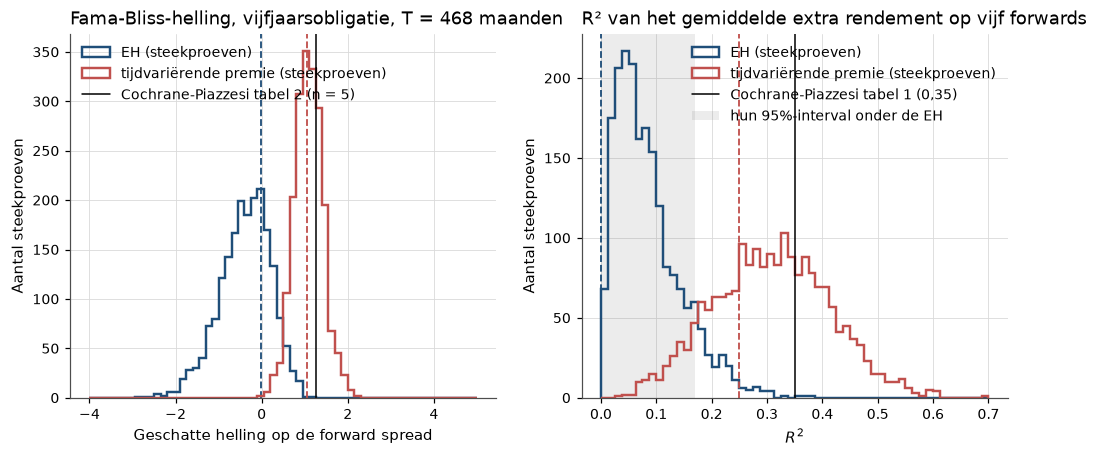

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
colours = {"EH": hap.plotting.COLORS[0], "tijdvariërende premie": hap.plotting.COLORS[1]}
for name, colour in colours.items():
    axes[0].hist(samples[name]["slope"], bins=np.linspace(-4, 5, 61), histtype="step", lw=1.6,
                 color=colour, label=f"{name} (steekproeven)")
    axes[0].axvline(population[name]["slope"][0], color=colour, ls="--", lw=1.2)
    axes[1].hist(samples[name]["r2_cp"], bins=np.linspace(0, 0.7, 57), histtype="step", lw=1.6,
                 color=colour, label=f"{name} (steekproeven)")
    axes[1].axvline(population[name]["r2_cp"][0], color=colour, ls="--", lw=1.2)
axes[0].axvline(1.27, color="black", lw=1.0, label="Cochrane-Piazzesi tabel 2 (n = 5)")
axes[0].set_title("Fama-Bliss-helling, vijfjaarsobligatie, T = 468 maanden")
axes[0].set_xlabel("Geschatte helling op de forward spread")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend(loc="upper left")
axes[1].axvline(0.35, color="black", lw=1.0, label="Cochrane-Piazzesi tabel 1 (0,35)")
axes[1].axvspan(0.0, 0.17, color="grey", alpha=0.15, lw=0, label="hun 95%-interval onder de EH")
axes[1].set_title("R² van het gemiddelde extra rendement op vijf forwards")
axes[1].set_xlabel("$R^2$")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend(loc="upper right")
plt.show()

:::{figure} #cel-termijnstructuur-premies-steekproef
:label: fig-termijnstructuur-premies-steekproef
:width: 100%

Links: onder de EH (blauw) is de ware helling nul, maar veertig jaar data laten in 95% van de
steekproeven $-1{,}7$ tot $+0{,}6$ toe; gestippeld de populatiewaarden. Rechts: vijf forwards op
overlappende jaarrendementen geven zonder enige voorspelbaarheid een $R^2$ tot 0,23. De grijze
band is het EH-interval van Cochrane en Piazzesi; hun 0,35 ligt erbuiten.
:::

De tabel en de figuur leren drie dingen. Ten eerste reproduceert het EH-model het
kleine-steekproefinterval van Cochrane en Piazzesi: de 97,5%-grens van de $R^2$ ligt
op 0,23, tegen hun 0,17. Vijf regressoren, persistente forwards en elf
maanden overlap blazen de $R^2$ op tot een orde van grootte die in een
aandelenregressie als een ontdekking zou gelden.

Ten tweede verwerpt de Hansen-Hodrick-toets de ware nulhypothese in 14% van de
steekproeven in plaats van 5%. Dat is het punt van Bauer en Hamilton in zijn eenvoudigste vorm: een $t$-waarde van 2 à 3 is
minder overtuigend dan hij lijkt, maar niet waardeloos.

Ten derde de richting van de fout. Met een echte premie (populatiehelling 1,05, populatie-$R^2$
0,25) loopt de vijfjaarshelling in 95% van de steekproeven van 0,45 tot 1,76, en de mediane
$R^2$ is 0,31: hoger dan de waarheid. Onder de EH is de mediane helling $-0{,}34$, een
Stambaugh-achtige vertekening als in [](#eq-voorspelbaarheid-stambaugh). Dat is motief 1 in de obligatiemarkt: extra rendementen op obligaties van twee tot vijf
jaar hebben volgens tabel 7 van Cochrane en Piazzesi een standaarddeviatie van 1,9 tot 6,0
procentpunt, veel minder dan de 20% van aandelen, en daarom is de premie hier sneller
zichtbaar dan in [](#04-20-voorspelbaarheid). Toch heeft een helling met veertig jaar data
nog een standaardfout van ongeveer een derde eenheid.

### Strings tegen factoren: de correlatiematrix

We vergelijken drie modellen voor maandelijkse forward-veranderingen op 1 tot 10 jaar, met
dezelfde volatiliteit per looptijd: één factor ($\rho_{ij} = 1$), een string met
$c = e^{-\kappa|\tau_i - \tau_j|}$ en $\kappa = 0{,}08$, en de beste benadering van die string
met drie factoren. Uit de string trekken we één steekproef van 600 maanden, en we berekenen de
volatiliteit van de swaprente voor een swaption op een swap van jaar 5 tot 10 met
[](#eq-termijnstructuur-premies-swaption).

In [5]:
TAU = np.arange(1, 11)
KAPPA_STRING = 0.08
VOL_FWD = 0.0030                                   # monthly forward-rate change volatility

corr_string = np.exp(-KAPPA_STRING * np.abs(TAU[:, None] - TAU[None, :]))


def rank_k_correlation(corr, k):
    """Best rank-k approximation of a correlation matrix, rescaled to a unit diagonal."""
    eigval, eigvec = np.linalg.eigh(corr)
    top = eigvec[:, -k:] * np.sqrt(eigval[-k:])
    approx = top @ top.T
    scale = np.sqrt(np.diag(approx))
    return approx / np.outer(scale, scale)


shocks = rng.standard_normal((600, len(TAU))) @ np.linalg.cholesky(corr_string).T * VOL_FWD
corr_sample = np.corrcoef(shocks.T)

eig_pop = np.sort(np.linalg.eigvalsh(corr_string))[::-1]
eig_sample = np.sort(np.linalg.eigvalsh(np.cov(shocks.T)))[::-1]

weights = np.full(5, 0.2)                          # swap rate ~ average of forwards 6..10 years
swaption_vol = {}
for label, corr in {"eenfactor": np.ones((10, 10)), "drie factoren": rank_k_correlation(corr_string, 3),
                    "string": corr_string}.items():
    block = corr[5:, 5:] * VOL_FWD**2
    swaption_vol[label] = np.sqrt(weights @ block @ weights)

print("aandeel eerste drie componenten, populatie: "
      f"{eig_pop[:3].sum() / eig_pop.sum():.3f}; steekproef: {eig_sample[:3].sum() / eig_sample.sum():.3f}")
print(f"correlatie 1 en 10 jaar: populatie {corr_string[0, -1]:.3f}, steekproef {corr_sample[0, -1]:.3f}")
pd.DataFrame(
    {"swaprente-vol (bp/maand)": {k: 1e4 * v for k, v in swaption_vol.items()},
     "prijs t.o.v. string": {k: v / swaption_vol["string"] for k, v in swaption_vol.items()}}
).round(3)

aandeel eerste drie componenten, populatie: 0.942; steekproef: 0.944
correlatie 1 en 10 jaar: populatie 0.487, steekproef 0.432


,swaprente-vol (bp/maand),prijs t.o.v. string
eenfactor,30.000,1.064
drie factoren,29.022,1.029
string,28.204,1.000


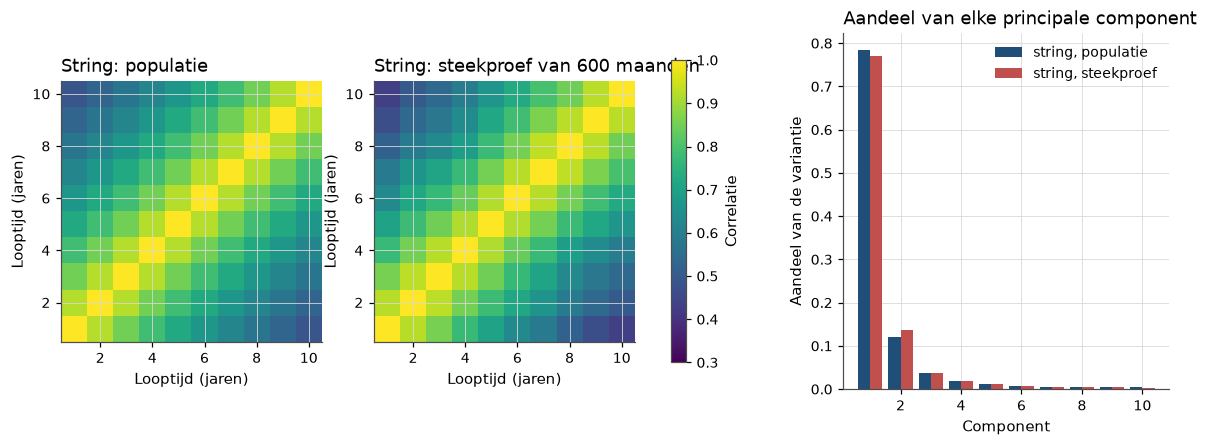

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (title, corr) in zip(axes[:2], [("String: populatie", corr_string),
                                        ("String: steekproef van 600 maanden", corr_sample)]):
    image = ax.imshow(corr, vmin=0.3, vmax=1.0, cmap="viridis", origin="lower", extent=(0.5, 10.5, 0.5, 10.5))
    ax.set_title(title)
    ax.set_xlabel("Looptijd (jaren)")
    ax.set_ylabel("Looptijd (jaren)")
fig.colorbar(image, ax=axes[:2], shrink=0.85, label="Correlatie")
axes[2].bar(np.arange(1, 11) - 0.2, eig_pop / eig_pop.sum(), width=0.4, label="string, populatie")
axes[2].bar(np.arange(1, 11) + 0.2, eig_sample / eig_sample.sum(), width=0.4, label="string, steekproef")
axes[2].set_title("Aandeel van elke principale component")
axes[2].set_xlabel("Component")
axes[2].set_ylabel("Aandeel van de variantie")
axes[2].legend()
plt.show()

:::{figure} #cel-termijnstructuur-premies-string
:label: fig-termijnstructuur-premies-string
:width: 100%

Een string heeft oneindig veel factoren, maar de PCA ziet er vertrouwd uit: de eerste drie
componenten dragen 94% van de variantie. Wie daaruit drie factoren concludeert, gooit de kleine
componenten weg die de correlaties tussen verre looptijden bepalen.
:::

Twee lessen. Een PCA met drie dominante componenten is geen bewijs voor drie factoren: een
continuüm aan schokken levert dezelfde tabel als die van Litterman en Scheinkman in
[](#03-17-termijnstructuur-real-options). En de kleine componenten zijn voor prijzen niet
klein: met dezelfde capprijzen prijst het eenfactormodel de swaption 6,4% hoger dan de string,
en ook het driefactormodel zit er 2,9% boven, omdat een benadering met lage rang de
correlaties tussen verre looptijden overschat. Tweede momenten zijn bovendien goed gemeten: de
steekproefcorrelatie van 1 en 10 jaar is 0,43 tegen 0,49 in de populatie. Het string-model repareert dus een fout die in de
data zichtbaar is.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** (1) Fama en Bliss, *The Information in Long-Maturity Forward Rates*, American
Economic Review 1987 {cite}`FamaBliss1987`, in de update van tabel 2 van (2) Cochrane en
Piazzesi, *Bond Risk Premia*, American Economic Review 2005 {cite}`CochranePiazzesi2005`.
(3) Campbell en Shiller, *Yield Spreads and Interest Rate Movements: A Bird's Eye View*,
Review of Economic Studies 1991 {cite}`CampbellShiller1991`, in de NBER-versie
(werkpaper 3153). (4) Santa-Clara en Sornette, *The Dynamics of the Forward Interest Rate
Curve with Stochastic String Shocks*, Review of Financial Studies 2001
{cite}`SantaClaraSornette2001`.

**Wat.** (1) Tabel 2 van Cochrane en Piazzesi: Fama-Bliss-hellingen 0,99; 1,35; 1,61; 1,27 met
$R^2$ 0,16; 0,17; 0,18; 0,09 (1964–2003). (2) Hun tabel 1: de tent, $R^2 = 0{,}35$,
$\hat b_n = 0{,}47;\ 0{,}87;\ 1{,}24;\ 1{,}43$; tabel 4: level, slope en curvature samen
$R^2 = 0{,}26$. (3) Tabel 1b van Campbell en Shiller (1952–1987, horizon één maand):
$b = -1{,}815$, $-3{,}099$ en $-5{,}024$ voor 24, 60 en 120 maanden. (4) De kwalitatieve
voorspelling van een string: de correlatie van forward-veranderingen daalt met het
looptijdverschil.

**Data hier.** De nulcouponcurve van Gürkaynak, Sack en Wright {cite}`GurkaynakSackWright2007`
via `hap.data.gsw()`: yields van 1 tot 10 jaar en instantane forwards, maandeinde, 1961-06 t/m
2026-08. Voor de maandhorizon van Campbell en Shiller berekenen we yields op looptijd
$n - 1/12$ met de Svensson-parameters uit hetzelfde bestand. Forecastdata $t$ lopen van
1964-01 t/m 1984-12 (de periode die aan Fama en Bliss wordt toegeschreven), t/m 2002-12
(Cochrane en Piazzesi) en t/m 2025-08 (het laatste rendement eindigt in 2026-08).

**Verschil met het origineel.** De papers gebruikten de Fama-Bliss-bestanden van CRSP:
nulcouponprijzen uit verhandelde obligaties, met hun meetfouten. GSW is een gladde
Svensson-curve met zes parameters. Die gladheid verwijdert juist de kleine,
looptijdspecifieke bewegingen waar de tent op leunt: de Cochrane-Piazzesi-$R^2$ moet lager
uitvallen en de tent kan vervlakken of verschuiven. Campbell en Shiller gebruikten McCulloch-data
vanaf 1952; GSW begint in 1961 en de éénmaandsrente is daar een extrapolatie. Een Svensson-curve
laat bovendien maar weinig onafhankelijke bewegingen toe, dus de string-intuïtie is alleen in
haar vorm te toetsen.

**Verwachte afwijking.** (1) Alle Fama-Bliss-hellingen positief en binnen ongeveer één
standaardfout van één, $R^2$ tussen 0,05 en 0,20. (2) De Cochrane-Piazzesi-$R^2$ duidelijk
hoger dan de Fama-Bliss-$R^2$ in dezelfde periode maar lager dan 0,35; $\hat b_n$ stijgend
in de looptijd; een negatief gewicht op $y^{(1)}$ en een positief gewicht in het midden. (3)
Alle Campbell-Shiller-hellingen onder één en voor lange looptijden negatief, dalend met de
looptijd. (4) De correlatie tussen veranderingen van de 1- en de 10-jaarsforward duidelijk
onder één, monotoon dalend met het looptijdverschil. Wijkt een *teken* af, dan zit de fout
in de code.
```

### De data

In [7]:
gsw_month = hap_data.gsw().resample("ME").last()
yields = pd.DataFrame({n: gsw_month[f"SVENY{n:02d}"] for n in range(1, 11)})
log_prices = -yields * yields.columns
forwards = pd.DataFrame({1: yields[1], **{n: log_prices[n - 1] - log_prices[n] for n in range(2, 11)}})
excess = pd.DataFrame({n: log_prices[n - 1].shift(-12) - log_prices[n] - yields[1] for n in range(2, 11)})

SAMPLES = {"1964-1985": ("1964-01", "1984-12"), "1964-2003": ("1964-01", "2002-12"),
           "1964-2026": ("1964-01", "2025-08")}
(100 * yields[[1, 2, 5, 10]].describe()).round(2)

,1,2,5,10
count,78300.00,78300.00,78300.00,66100.00
mean,4.81,4.99,5.41,5.96
std,3.25,3.20,3.01,3.00
min,0.07,0.11,0.24,0.55
25%,2.30,2.67,3.39,3.83
50%,4.83,4.85,5.17,5.81
75%,6.62,6.84,7.27,7.76
max,16.11,15.78,15.18,14.89


### Fama en Bliss: de spread voorspelt het rendement, niet de rente

In [8]:
def ols_hac(y, X, lags, kernel="bartlett"):
    """OLS with an intercept and HAC standard errors (kernel 'uniform' = Hansen-Hodrick)."""
    frame = pd.concat([y.rename("y"), X], axis=1).dropna()
    return sm.OLS(frame["y"], sm.add_constant(frame.drop(columns="y"))).fit(
        cov_type="HAC", cov_kwds={"maxlags": lags, "kernel": kernel})


def fama_bliss_table(start, end):
    """Fama-Bliss (1987) regressions of rx^(n) on f^(n) - y^(1), Hansen-Hodrick SEs with 12 lags."""
    rows = {}
    for n in range(2, 6):
        spread = (forwards[n] - yields[1]).rename("spread").loc[start:end]
        fit = ols_hac(excess[n].loc[start:end], spread, lags=12, kernel="uniform")
        rows[n] = {"helling": fit.params["spread"], "SE (HH)": fit.bse["spread"],
                   "t (helling = 0)": fit.tvalues["spread"], "R2": fit.rsquared, "nobs": int(fit.nobs)}
    return pd.DataFrame(rows).T.rename_axis("n")


fb_tables = {label: fama_bliss_table(*period) for label, period in SAMPLES.items()}
fb_view = pd.concat({label: table[["helling", "SE (HH)", "t (helling = 0)", "R2"]]
                     for label, table in fb_tables.items()}, axis=1)
fb_view[("CP tabel 2", "helling")] = [0.99, 1.35, 1.61, 1.27]
fb_view[("CP tabel 2", "R2")] = [0.16, 0.17, 0.18, 0.09]
fb_view.round(3)

1964-1985                                1964-2003                          \
    helling SE (HH) t (helling = 0)     R2   helling SE (HH) t (helling = 0)   
n                                                                              
2     0.917   0.336           2.728  0.106     0.965   0.321           3.008   
3     0.996   0.446           2.232  0.079     1.198   0.424           2.824   
4     1.069   0.584           1.829  0.064     1.403   0.522           2.687   
5     1.163   0.730           1.592  0.054     1.594   0.607           2.626   

         1964-2026                                CP tabel 2        
      R2   helling SE (HH) t (helling = 0)     R2    helling    R2  
n                                                                   
2  0.124     0.721   0.274           2.627  0.077       0.99  0.16  
3  0.126     0.878   0.342           2.567  0.081       1.35  0.17  
4  0.127     1.039   0.383           2.716  0.089       1.61  0.18  
5  0.126     1.201   0.408           2.940  0.098       1.27  0.09

Alle hellingen zijn positief en liggen binnen één standaardfout van één, ver van de nul van de
EH. Over 1964–2003 vinden we 0,97; 1,20; 1,40 en 1,59 tegen 0,99; 1,35; 1,61 en 1,27, met $R^2$
van 0,12–0,13 binnen hun band van 0,09–0,18. Over 1964–1985 zijn hellingen (0,92–1,16) en $R^2$
(0,05–0,11) lager dan de "about 18 percent" waarmee Cochrane en Piazzesi Fama en Bliss
samenvatten; tot 2026 blijft het patroon staan (hellingen 0,72–1,20, $R^2$ 0,08–0,10).

De standaardfouten verdienen aandacht (motief 1). Een helling van 1,2 met standaardfout 0,4
verwerpt de EH met $t \approx 3$, maar 0,4 of 2,0 zou evengoed binnen twee standaardfouten
liggen, en de simulatie liet zien dat de Hansen-Hodrick-$t$ hier te vaak verwerpt. De tekens
zijn robuust, de precieze getallen niet.

### Cochrane en Piazzesi: de tent op een gladde curve

In [9]:
def cochrane_piazzesi(start, end):
    """Two-step Cochrane-Piazzesi (2005) estimates on 1..5-year forwards."""
    data = pd.concat([excess[[2, 3, 4, 5]], forwards[[1, 2, 3, 4, 5]].add_prefix("f")], axis=1)
    data = data.loc[start:end].dropna()
    regressors = data[[f"f{k}" for k in range(1, 6)]]
    avg_rx = data[[2, 3, 4, 5]].mean(axis=1).rename("avg")
    step1 = ols_hac(avg_rx, regressors, lags=18)
    factor = sm.add_constant(regressors) @ step1.params
    per_n = {}
    for n in range(2, 6):
        b_n = float((factor * data[n]).sum() / (factor**2).sum())      # no intercept, as in CP
        unrestricted = sm.OLS(data[n], sm.add_constant(regressors)).fit()
        per_n[n] = {"b_n": b_n, "R2 beperkt": data[n].corr(factor) ** 2, "R2 onbeperkt": unrestricted.rsquared}
    return step1, factor, pd.DataFrame(per_n).T.rename_axis("n")


cp_fits = {label: cochrane_piazzesi(*SAMPLES[label]) for label in ["1964-2003", "1964-2026"]}
gamma_names = ["const (%)", "y1", "f2", "f3", "f4", "f5"]
gamma_view = pd.DataFrame(
    {label: np.append(100 * fit[0].params.iloc[0], fit[0].params.iloc[1:]) for label, fit in cp_fits.items()},
    index=gamma_names)
gamma_view["CP tabel 1"] = [-3.24, -2.14, 0.81, 3.00, 0.80, -2.08]
gamma_view.loc["R2 gemiddeld rx"] = [cp_fits["1964-2003"][0].rsquared, cp_fits["1964-2026"][0].rsquared, 0.35]
gamma_view.loc["Wald chi2(5), NW 18"] = [float(fit[0].wald_test(np.eye(6)[1:], scalar=True).statistic)
                                         for fit in cp_fits.values()] + [105.5]
gamma_view.round(2)

,1964-2003,1964-2026,CP tabel 1
const (%),-3.09,-1.62,-3.24
y1,-2.93,-2.46,-2.14
f2,3.80,7.18,0.81
f3,0.15,-11.54,3.00
f4,-0.90,8.24,0.80
f5,0.27,-1.17,-2.08
R2 gemiddeld rx,0.24,0.15,0.35
"Wald chi2(5), NW 18",33.98,23.81,105.50


In [10]:
per_maturity = pd.concat({label: fit[2] for label, fit in cp_fits.items()}, axis=1)
per_maturity[("CP tabel 1", "b_n")] = [0.47, 0.87, 1.24, 1.43]
per_maturity[("CP tabel 1", "R2 beperkt")] = [0.31, 0.34, 0.37, 0.34]
per_maturity.round(3)

1964-2003                         1964-2026                          \
        b_n R2 beperkt R2 onbeperkt       b_n R2 beperkt R2 onbeperkt   
n                                                                       
2     0.462      0.202        0.206     0.449      0.130        0.140   
3     0.851      0.228        0.228     0.836      0.141        0.142   
4     1.191      0.246        0.246     1.191      0.153        0.153   
5     1.495      0.258        0.259     1.525      0.164        0.166   

  CP tabel 1             
         b_n R2 beperkt  
n                        
2       0.47       0.31  
3       0.87       0.34  
4       1.24       0.37  
5       1.43       0.34

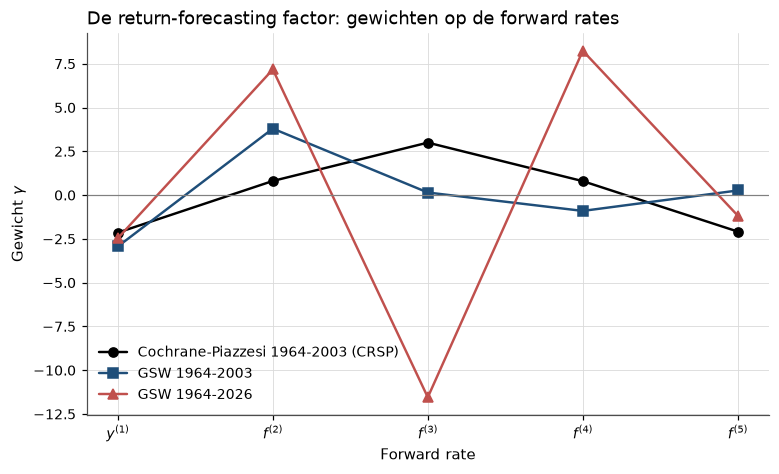

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, 6), [-2.14, 0.81, 3.00, 0.80, -2.08], marker="o", color="black",
        label="Cochrane-Piazzesi 1964-2003 (CRSP)")
ax.plot(range(1, 6), cp_fits["1964-2003"][0].params.iloc[1:].to_numpy(), marker="s",
        color=hap.plotting.COLORS[0], label="GSW 1964-2003")
ax.plot(range(1, 6), cp_fits["1964-2026"][0].params.iloc[1:].to_numpy(), marker="^",
        color=hap.plotting.COLORS[1], label="GSW 1964-2026")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(range(1, 6), ["$y^{(1)}$", "$f^{(2)}$", "$f^{(3)}$", "$f^{(4)}$", "$f^{(5)}$"])
ax.set_title("De return-forecasting factor: gewichten op de forward rates")
ax.set_xlabel("Forward rate")
ax.set_ylabel("Gewicht $\\gamma$")
ax.legend()
plt.show()

:::{figure} #cel-termijnstructuur-premies-tent
:label: fig-termijnstructuur-premies-tent
:width: 85%

De tent van Cochrane en Piazzesi (zwart) naast dezelfde regressie op de gladde GSW-curve.
Over 1964–2003 (blauw) blijven het negatieve gewicht op de éénjaarsrente en het positieve
midden staan, maar de top schuift van $f^{(3)}$ naar $f^{(2)}$ en de rechterpoot verdwijnt.
Tot 2026 (rood) wisselen de gewichten wild van teken: de vijf forwards van een gladde curve
zijn bijna collineair, en kleine verschillen in hun onderlinge bewegingen krijgen grote,
tegengestelde coëfficiënten.
:::

Op GSW over 1964–2003 verklaart de factor 24% van de variantie van het gemiddelde extra
rendement, tegen 35% bij Cochrane en Piazzesi en 12–13% per Fama-Bliss-regressie. De ladingen
$\hat b_n = 0{,}46;\ 0{,}85;\ 1{,}19;\ 1{,}50$ liggen vrijwel op de gepubliceerde, en de
onbeperkte regressies komen nauwelijks hoger uit: de éénfactorstructuur overleeft. De tent is
minder scherp, en de Newey-West-$\chi^2(5)$ is 34 tegen 105,5 (kritieke waarde 15,1 op 1%). Tot
2026 zakt de $R^2$ naar 0,15 en worden de gewichten onleesbaar.

Dat voorspelde het replicatieblok: een curve met zes parameters kan de kleine,
looptijdspecifieke bewegingen waar de factor deels op leunt maar beperkt maken.

Hoeveel van die voorspelling zit in level, slope en curvature? We herhalen tabel 4 van
Cochrane en Piazzesi: principale componenten van de yieldniveaus van 1 tot 5 jaar,
en de $R^2$ van het gemiddelde extra rendement op de eerste één, twee, drie en vijf
componenten.

In [12]:
def pca_regressions(start, end):
    """R2 of average excess returns on the first k principal components of 1-5 year yields."""
    data = pd.concat([excess[[2, 3, 4, 5]].mean(axis=1).rename("avg"), yields[[1, 2, 3, 4, 5]]], axis=1)
    data = data.loc[start:end].dropna()
    levels = data[[1, 2, 3, 4, 5]]
    eigval, eigvec = np.linalg.eigh(np.cov(levels.to_numpy().T))
    order = np.argsort(eigval)[::-1]
    scores = pd.DataFrame((levels - levels.mean()).to_numpy() @ eigvec[:, order],
                          index=levels.index, columns=[f"pc{k}" for k in range(1, 6)])
    out = {}
    for label, cols in {"slope (pc2)": ["pc2"], "level, slope": ["pc1", "pc2"],
                        "level, slope, curvature": ["pc1", "pc2", "pc3"],
                        "alle vijf": [f"pc{k}" for k in range(1, 6)]}.items():
        out[label] = sm.OLS(data["avg"], sm.add_constant(scores[cols])).fit().rsquared
    out["variantie-aandeel pc4 + pc5 (miljoensten)"] = 1e6 * eigval[order][3:].sum() / eigval.sum()
    return pd.Series(out)


pd.DataFrame({"GSW 1964-2003": pca_regressions(*SAMPLES["1964-2003"]),
              "GSW 1964-2026": pca_regressions(*SAMPLES["1964-2026"]),
              "CP tabel 4": [0.22, 0.24, 0.26, 0.35, np.nan]}).round(4)

,GSW 1964-2003,GSW 1964-2026,CP tabel 4
slope (pc2),0.1907,0.1223,0.22
"level, slope",0.2130,0.1365,0.24
"level, slope, curvature",0.2428,0.1370,0.26
alle vijf,0.2435,0.1535,0.35
variantie-aandeel pc4 + pc5 (miljoensten),7.2311,4.6250,NaN


Hier zit het wezenlijke verschil met het artikel. Op GSW verklaren level, slope en curvature
over 1964–2003 een $R^2$ van 0,243, en alle vijf componenten 0,244: de laatste twee
componenten voegen niets toe, en hun aandeel in de variantie van de yieldniveaus is
verwaarloosbaar (laatste rij, in miljoensten). Bij Cochrane en Piazzesi stijgt de $R^2$ van
0,26 naar 0,35 door precies die kleine componenten. Het deel van de premie dat volgens
[](#thm-termijnstructuur-premies-verborgen) klein is voor rentes en groot voor rendementen,
is in de gladde GSW-curve weggestreken. De slope alleen haalt 0,19 (Cochrane en Piazzesi:
0,22), en dat deel repliceert wel. De vraag van Bauer en Hamilton, of informatie buiten level, slope en curvature robuust is, is
met deze data dus niet te beantwoorden: de data bevatten die informatie niet meer.

### Campbell en Shiller: de lange rente beweegt de verkeerde kant op

We schatten [](#eq-termijnstructuur-premies-cs) op twee manieren: met een horizon van één
jaar voor looptijden van 2 tot 10 jaar (jaarstappen, zoals de Fama-Bliss-regressie), en
met een horizon van één maand voor looptijden van 24, 60 en 120 maanden, zoals in tabel 1b
van Campbell en Shiller. Voor dat laatste hebben we yields nodig op looptijden als 59
maanden en de rente op één maand; die leveren de Svensson-parameters van GSW.

In [13]:
def svensson_yield(params, tau):
    """Continuously compounded Svensson (1994) zero yield at maturity tau (years), row-wise."""
    b3 = params["BETA3"].fillna(0.0)
    t1, t2 = params["TAU1"], params["TAU2"].fillna(1.0)
    x1, x2 = tau / t1, tau / t2
    hump1 = (1 - np.exp(-x1)) / x1
    return (params["BETA0"] + params["BETA1"] * hump1 + params["BETA2"] * (hump1 - np.exp(-x1))
            + b3 * ((1 - np.exp(-x2)) / x2 - np.exp(-x2)))


svensson = gsw_month[["BETA0", "BETA1", "BETA2", "BETA3", "TAU1", "TAU2"]].dropna(subset=["BETA0", "TAU1"])
check = (svensson_yield(svensson, 5.0) - gsw_month.loc[svensson.index, "SVENY05"]).abs().max()
print(f"grootste afwijking Svensson-formule t.o.v. SVENY05: {check:.2e}")


def campbell_shiller(n_years, horizon_years, start, end):
    """Campbell-Shiller (1991) slope: change in the (n-h)-yield over h on h/(n-h) times the (n,h) spread."""
    h, n = horizon_years, n_years
    long_now, long_next = svensson_yield(svensson, n), svensson_yield(svensson, n - h)
    short_now = svensson_yield(svensson, h)
    steps = int(round(12 * h))
    lhs = (long_next.shift(-steps) - long_now).rename("lhs")
    x = (h / (n - h) * (long_now - short_now)).rename("spread")
    fit = ols_hac(lhs.loc[start:end], x.loc[start:end], lags=max(steps, 1) - 1 + 1, kernel="uniform")
    return fit.params["spread"], fit.bse["spread"], int(fit.nobs)


annual_rows = {}
for n in range(2, 11):
    first = "1964-01" if n <= 7 else "1971-08"
    b_03, se_03, _ = campbell_shiller(n, 1.0, first, "2002-12")
    b_26, se_26, _ = campbell_shiller(n, 1.0, first, "2025-08")
    annual_rows[n] = {"start": first[:4], "b t/m 2003": b_03, "SE": se_03, "b t/m 2026": b_26, "SE ": se_26}
pd.DataFrame(annual_rows).T.rename_axis("n (jaren)").round(3)

grootste afwijking Svensson-formule t.o.v. SVENY05: 5.00e-07


,start,b t/m 2003,SE,b t/m 2026,SE
n (jaren),,,,,
2,1964,-0.929959,0.641588,-0.441147,0.548526
3,1964,-1.269448,0.736132,-0.687838,0.620204
4,1964,-1.544052,0.828797,-0.931385,0.666794
5,1964,-1.781989,0.913113,-1.166234,0.697297
6,1964,-1.997576,0.988982,-1.388553,0.719716
7,1964,-2.198698,1.058677,-1.596831,0.739739
8,1971,-2.350057,1.23713,-1.725805,0.818079
9,1971,-2.533305,1.31969,-1.905554,0.850722
10,1971,-2.713191,1.404469,-2.07555,0.888117


In [14]:
monthly_rows = {}
for months, published in [(24, -1.815), (60, -3.099), (120, -5.024)]:
    first = "1961-07" if months <= 84 else "1971-08"
    b_87, se_87, n_87 = campbell_shiller(months / 12, 1 / 12, first, "1987-01")
    b_26, se_26, n_26 = campbell_shiller(months / 12, 1 / 12, first, "2026-07")
    monthly_rows[months] = {"b t/m 1987": b_87, "SE (HH)": se_87, "nobs": n_87,
                            "b t/m 2026": b_26, "SE (HH) ": se_26, "CS tabel 1b (1952-1987)": published}
pd.DataFrame(monthly_rows).T.rename_axis("looptijd (maanden)").round(3)

,b t/m 1987,SE (HH),nobs,b t/m 2026,SE (HH),CS tabel 1b (1952-1987)
looptijd (maanden),,,,,,
24,-0.049,0.381,307.0,-0.066,0.339,-1.815
60,-0.401,0.739,307.0,-0.596,0.604,-3.099
120,-3.214,2.632,186.0,-2.576,1.389,-5.024


Met een horizon van één jaar zijn alle hellingen negatief en dalen ze met de looptijd: van
$-0{,}93$ (twee jaar) tot $-2{,}71$ (tien jaar) tot 2003, en van $-0{,}44$ tot $-2{,}08$ tot 2026.
Elke helling ligt 2,6 tot 3,5 standaardfouten onder de één van de EH. Oefening
[](#ex-termijnstructuur-premies-1) laat zien dat ze exact $1 - \beta^s_n$ zijn.

Met een horizon van één maand komen we minder dicht bij tabel 1b. Teken en rangorde kloppen:
$-0{,}05$, $-0{,}40$ en $-3{,}21$ voor 24, 60 en 120 maanden tot 1987, tegen $-1{,}82$,
$-3{,}10$ en $-5{,}02$. De omvang niet. De waarschijnlijke oorzaak is de éénmaandsrente, bij GSW een extrapolatie van
de curve: een meetfout in de korte rente zit volledig in de regressor en trekt de helling naar
nul. Bij een horizon van een jaar speelt dat nauwelijks. Onze steekproef begint bovendien in
1961 in plaats van 1952.

### Forward-veranderingen: correlatie daalt met de afstand

In [15]:
inst_fwd = pd.DataFrame({n: gsw_month[f"SVENF{n:02d}"] for n in range(1, 11)}).dropna()
fwd_changes = inst_fwd.diff().dropna()
corr_data = fwd_changes.corr()

distance = np.abs(TAU[:, None] - TAU[None, :])
off_diag = distance > 0
kappa_fit = float((distance[off_diag] * -np.log(corr_data.to_numpy()[off_diag])).sum() / (distance[off_diag] ** 2).sum())
eig_data = np.sort(np.linalg.eigvalsh(fwd_changes.cov().to_numpy()))[::-1]

print(f"steekproef {fwd_changes.index[0]:%Y-%m} t/m {fwd_changes.index[-1]:%Y-%m}, {len(fwd_changes)} maanden")
print(f"gefitte kappa in exp(-kappa |dtau|): {kappa_fit:.3f}")
print(f"aandeel eerste drie componenten: {eig_data[:3].sum() / eig_data.sum():.3f}")
corr_data.round(2)

steekproef 1971-09 t/m 2026-08, 660 maanden
gefitte kappa in exp(-kappa |dtau|): 0.075
aandeel eerste drie componenten: 0.990


,1,2,3,4,5,6,7,8,9,10
1,1.00,0.92,0.79,0.69,0.63,0.58,0.55,0.52,0.49,0.47
2,0.92,1.00,0.95,0.87,0.79,0.72,0.66,0.61,0.57,0.54
3,0.79,0.95,1.00,0.97,0.91,0.85,0.78,0.71,0.66,0.61
4,0.69,0.87,0.97,1.00,0.98,0.94,0.87,0.81,0.74,0.69
5,0.63,0.79,0.91,0.98,1.00,0.98,0.94,0.89,0.83,0.77
6,0.58,0.72,0.85,0.94,0.98,1.00,0.99,0.95,0.91,0.86
7,0.55,0.66,0.78,0.87,0.94,0.99,1.00,0.99,0.96,0.92
8,0.52,0.61,0.71,0.81,0.89,0.95,0.99,1.00,0.99,0.97
9,0.49,0.57,0.66,0.74,0.83,0.91,0.96,0.99,1.00,0.99
10,0.47,0.54,0.61,0.69,0.77,0.86,0.92,0.97,0.99,1.00


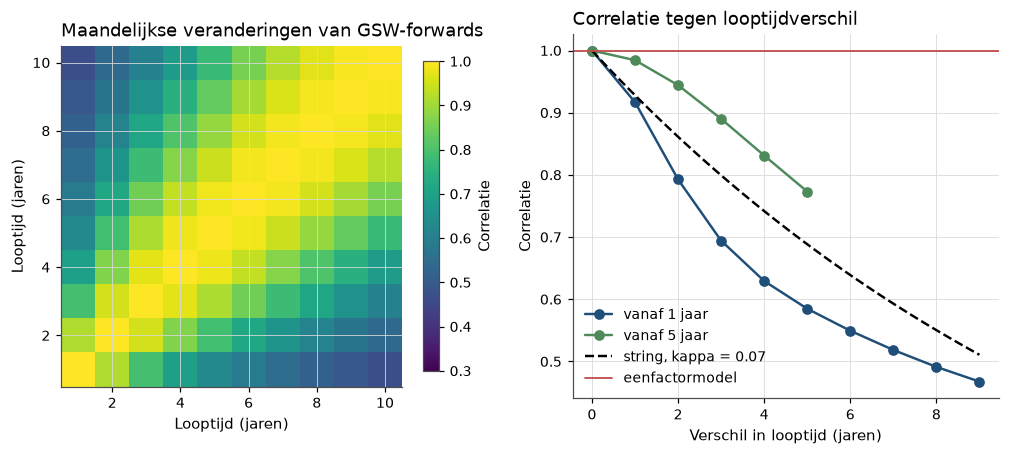

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
image = axes[0].imshow(corr_data.to_numpy(), vmin=0.3, vmax=1.0, cmap="viridis", origin="lower",
                       extent=(0.5, 10.5, 0.5, 10.5))
fig.colorbar(image, ax=axes[0], shrink=0.85, label="Correlatie")
axes[0].set_title("Maandelijkse veranderingen van GSW-forwards")
axes[0].set_xlabel("Looptijd (jaren)")
axes[0].set_ylabel("Looptijd (jaren)")

for start, colour in [(1, hap.plotting.COLORS[0]), (5, hap.plotting.COLORS[2])]:
    axes[1].plot(TAU[start - 1:] - start, corr_data.loc[start, start:].to_numpy(), marker="o", color=colour,
                 label=f"vanaf {start} jaar")
d_grid = np.linspace(0, 9, 50)
axes[1].plot(d_grid, np.exp(-kappa_fit * d_grid), color="black", ls="--", label=f"string, kappa = {kappa_fit:.2f}")
axes[1].axhline(1.0, color=hap.plotting.COLORS[1], lw=1.2, label="eenfactormodel")
axes[1].set_title("Correlatie tegen looptijdverschil")
axes[1].set_xlabel("Verschil in looptijd (jaren)")
axes[1].set_ylabel("Correlatie")
axes[1].legend()
plt.show()

:::{figure} #cel-termijnstructuur-premies-correlatie
:label: fig-termijnstructuur-premies-correlatie
:width: 100%

Links: correlaties van maandelijkse veranderingen in de instantane GSW-forwards van 1 tot 10
jaar, 1971–2026. Rechts: de correlatie vanaf de 1- en de 5-jaarsforward tegen het
looptijdverschil, naast een string met de gefitte $\kappa$ en het eenfactormodel. De
correlatie daalt monotoon met de afstand, zoals een string voorspelt, maar ze hangt niet
alleen van de afstand af: aan de lange kant blijven buren sterker gecorreleerd dan aan de
korte kant.
:::

De correlatie tussen veranderingen van de 1- en de 10-jaarsforward is 0,47, tussen buren 0,92
(kort) tot 0,99 (lang), en elke rij daalt monotoon met de afstand. Een fit van $-\log\rho$ op de
afstand geeft $\kappa = 0{,}075$, dicht bij de 0,08 uit de simulatie; een eenfactormodel zou
overal één geven. Dat buren aan de lange kant sterker samenhangen, vraagt een kern die niet
alleen van het looptijdverschil afhangt, en die vrijheid laat het string-model.

Twee kanttekeningen. De eerste drie componenten dragen 99,0% van de variantie, meer dan de 94%
van de string, maar dat zegt vooral iets over GSW: bij vaste $\tau_1$ en $\tau_2$ bewegen de
forwards van een Svensson-curve in zes dimensies. De vorm van de matrix toetst de
string-intuïtie, het aantal factoren niet. En tweede momenten zijn goed gemeten: met 660
maanden is de standaardfout van een correlatie rond 0,5 ongeveer
$(1-0{,}5^2)/\sqrt{660} \approx 0{,}03$; het verschil tussen 0,47 en één is geen ruis.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** De expectations hypothesis is een schoon en bruikbaar
uitgangspunt: ze maakt van de rentecurve een voorspelling, en die voorspelling is voor de
korte kant niet eens slecht. De identiteit [](#eq-termijnstructuur-premies-identiteit)
laat zien waarom ze zo lang overeind bleef: een forward spread moet óf in renteveranderingen
óf in extra rendementen terechtkomen, en zolang niemand naar het tweede keek, leek het
eerste vanzelfsprekend. De affiene modellen en de HJM-benadering bleven bestaan, met een tijdvariërende prijs van
risico of een rijkere correlatiestructuur erbij.

**Waar het breekt.** Op GSW-data over 1964–2003 heeft de Fama-Bliss-regressie hellingen
van ongeveer één in plaats van nul, en de Campbell-Shiller-hellingen zijn negatief in plaats
van één; beide blijven zo tot 2026. Eén tentvormige combinatie van forwards voorspelt het
gemiddelde extra rendement met een $R^2$ van 0,24 op GSW, tegen 0,35 op de
CRSP-data van Cochrane en Piazzesi. En de correlaties van forward-veranderingen dalen van
0,92 à 0,99 voor buren naar 0,47 tussen één en tien jaar, iets wat een
eenfactormodel niet kan en een model met drie factoren alleen bij benadering. Wat níet
robuust is, is de precieze vorm van de tent en de hoogte van de $R^2$: de simulatie laat zien
dat vijf forwards met overlap onder de EH al een $R^2$ tot 0,23 kunnen halen; op GSW voegen de
componenten buiten level, slope en curvature niets toe; buiten de steekproef verliest de
factor van het gemiddelde (oefening [](#ex-termijnstructuur-premies-2)); en
Bauer en Hamilton concluderen dat het bewijs voor voorspellers buiten level, slope en
curvature "much weaker than it originally appeared" is.

**Risico of vergissing?** De Chicago-lezing: de premie vergoedt renterisico dat in slechte tijden toeslaat. Cochrane en
Piazzesi noemen hun factor contracyclisch en hij voorspelt ook aandelenrendementen (helling 1,73 in
hun tabel 3); Ludvigson en Ng vinden contracyclische macrofactoren in de premie. Dat is wat een
SDF met tijdvariërende prijs van risico, zoals in [](#05-27-drie-antwoorden), vereist. De
Yale-lezing: gesegmenteerde markten, pensioenfondsen en centrale banken die lange looptijden
ongeacht de prijs kopen, geëxtrapoleerde inflatie en arbitrageurs met beperkt kapitaal. De
"major pricing distortions" van 1998 in swaptions passen beter bij die lezing. De data
scheiden de lezingen niet: een contracyclische premie is de voorspelling van beide. Voor
Santa-Clara's praktijkmotief is het onderscheid scherp. Wie lange obligaties koopt als
de tent hoog staat, draagt ofwel "risk that was priced", ofwel denkt hij iets te weten
wat de prijs niet weet; en wie swaptions met een eenfactormodel prijst terwijl de markt
correlaties onder één prijst, zit in het tweede geval zonder het te merken.

**Wat er daarna kwam.** Als de prijs van risico in obligaties voorspelbaar varieert en
correlaties tussen looptijden in optieprijzen besloten liggen, is de volgende vraag wat
optieprijzen op aandelen zeggen over het risico van een crash: zie
[](#05-29-opties-crashrisico).

## Oefeningen

:::{exercise}
:label: ex-termijnstructuur-premies-1

**Campbell-Shiller uit Fama-Bliss.** Neem de jaarlijkse horizon en $n = 2,\dots,5$.

1. Laat met [](#thm-termijnstructuur-premies-cs-fb) zien dat onder de hypothese
   $\E_t[rx^{(n)}_{t+1}] = s_t$ (de spread is volledig premie) de Campbell-Shiller-helling
   nul is. Welke waarde van $b_n$ hoort bij een Fama-Bliss-helling van één op de forward
   spread als $n = 2$?
2. Schat op GSW over 1964–2003 per $n$ de helling $\beta^s_n$ van $rx^{(n)}_{t+1}$ op
   $s_t = y^{(n)}_t - y^{(1)}_t$ en de Campbell-Shiller-helling $b_n$. Controleer dat
   $b_n = 1 - \beta^s_n$ op machineprecisie.
3. Bereken voor $n = 2$ ook $1 - 2\hat\beta_2$ met $\hat\beta_2$ uit de Fama-Bliss-tabel.
:::

:::{solution} ex-termijnstructuur-premies-1
:class: dropdown

**(1)** Als $\E_t[rx^{(n)}_{t+1}] = s_t$ en de projectie van $rx$ op $s$ dus helling één
heeft, is $b_n = 1 - 1 = 0$: de lange rente beweegt gemiddeld niet. Voor $n = 2$ is de
forward spread $2s_t$, dus een Fama-Bliss-helling van één betekent $\beta^s_2 = 2$ en
$b_2 = -1$.

**(2) en (3)**

In [17]:
start, end = SAMPLES["1964-2003"]
rows_ex1 = {}
for n in range(2, 6):
    spread_n = (yields[n] - yields[1]).rename("s")
    lhs_cs = ((yields[n - 1].shift(-12) - yields[n]).rename("lhs"))
    beta_s = sm.OLS(excess[n].loc[start:end], sm.add_constant(spread_n.loc[start:end]), missing="drop").fit().params["s"]
    b_cs = sm.OLS(lhs_cs.loc[start:end], sm.add_constant(spread_n.loc[start:end] / (n - 1)),
                  missing="drop").fit().params["s"]
    rows_ex1[n] = {"beta^s": beta_s, "b_CS": b_cs, "1 - beta^s": 1 - beta_s}
table_ex1 = pd.DataFrame(rows_ex1).T.rename_axis("n")
assert np.allclose(table_ex1["b_CS"], table_ex1["1 - beta^s"])
print(f"n = 2: 1 - 2 * FB-helling = {1 - 2 * fb_tables['1964-2003'].loc[2, 'helling']:.4f}")
table_ex1.round(4)

n = 2: 1 - 2 * FB-helling = -0.9300


,beta^s,b_CS,1 - beta^s
n,,,
2,1.9300,-0.9300,-0.9300
3,2.2695,-1.2695,-1.2695
4,2.5441,-1.5441,-1.5441
5,2.7820,-1.7820,-1.7820


De identiteit sluit exact, en voor $n = 2$ is $1 - 2\hat\beta_2$ gelijk aan $b_2$. De les:
de negatieve Campbell-Shiller-hellingen en de positieve Fama-Bliss-hellingen zijn één
feit, dat de spread vooral premie en weinig renteverwachting bevat.
:::

:::{exercise}
:label: ex-termijnstructuur-premies-2

**Vertraagde forwards en een test buiten de steekproef.** Cochrane en Piazzesi vonden in
hun tabel 5 dat de $R^2$ oploopt tot 0,44 als de regressor een gemiddelde is van de forwards
van de laatste vier maanden.

1. Vervang op GSW over 1964–2003 in de eerste stap $\mathbf f_t$ door
   $\tfrac14(\mathbf f_t + \mathbf f_{t-1} + \mathbf f_{t-2} + \mathbf f_{t-3})$ (gelijke
   gewichten) en rapporteer de $R^2$ van het gemiddelde extra rendement, naast die zonder
   vertragingen.
2. Neem $\hat{\boldsymbol\gamma}$ uit 1964–2003 (zonder vertragingen), en voorspel
   daarmee de gemiddelde extra rendementen voor forecastdata 2003-01 t/m 2025-08. Bereken
   de out-of-sample $R^2$ tegen het gemiddelde extra rendement van 1964–2003.
:::

:::{solution} ex-termijnstructuur-premies-2
:class: dropdown

In [18]:
fwd_cols = [1, 2, 3, 4, 5]
avg_excess = excess[[2, 3, 4, 5]].mean(axis=1).rename("avg")
start, end = SAMPLES["1964-2003"]

r2_by_lag = {}
for lags in (0, 3):
    smoothed = forwards[fwd_cols].rolling(lags + 1).mean().add_prefix("f")
    r2_by_lag[f"forwards t..t-{lags}"] = ols_hac(avg_excess.loc[start:end], smoothed.loc[start:end], lags=18).rsquared

gamma_in = cp_fits["1964-2003"][0].params.to_numpy()
oos = pd.concat([avg_excess, forwards[fwd_cols]], axis=1).loc["2003-01":"2025-08"].dropna()
forecast = gamma_in[0] + oos[fwd_cols].to_numpy() @ gamma_in[1:]
benchmark = avg_excess.loc[start:end].mean()
r2_oos = 1 - ((oos["avg"] - forecast) ** 2).sum() / ((oos["avg"] - benchmark) ** 2).sum()

pd.Series({**r2_by_lag, "CP tabel 5 (0 en 3 vertragingen)": "0.35 / 0.44",
           "OOS R2 2003-2025 met gamma uit 1964-2003": r2_oos,
           "gemiddelde voorspelling 2003-2025 (%)": 100 * forecast.mean(),
           "gemiddeld gerealiseerd 2003-2025 (%)": 100 * oos["avg"].mean(),
           "gemiddelde 1964-2003 (%)": 100 * benchmark}).apply(lambda v: round(v, 3) if isinstance(v, float) else v)

forwards t..t-0                                   0.243
forwards t..t-3                                   0.258
CP tabel 5 (0 en 3 vertragingen)            0.35 / 0.44
OOS R2 2003-2025 met gamma uit 1964-2003         -1.173
gemiddelde voorspelling 2003-2025 (%)            -1.947
gemiddeld gerealiseerd 2003-2025 (%)              0.606
gemiddelde 1964-2003 (%)                          0.849
dtype: object

Met een gemiddelde over vier maanden stijgt de $R^2$ op GSW van 0,24 naar 0,26, veel minder dan
de stap van 0,35 naar 0,44 bij Cochrane en Piazzesi: een gladde curve bevat al minder meetruis.
Buiten de steekproef faalt de factor: de $R^2_{OOS}$ over 2003–2025 is $-1{,}17$. Hij voorspelde
gemiddeld $-1{,}9\%$ per jaar tegen een gerealiseerde $+0{,}6\%$, omdat de constante ($-3{,}1\%$)
en de gewichten (som 0,39) niet neutraal zijn voor het renteniveau: bij rentes rond nul voorspelt
de tent een negatieve premie. Les: in de steekproef sterk, buiten de steekproef instabiel.
:::